# CLABTOOLKIT — Practical Examples

> **Package:** `clabtoolkit` · **Authors:** Yasser Alemán-Gómez, Nino Herve · **Version:** latest

---

### Short description

🧠 CLABTOOLKIT Tutorial
**What is CLABTOOLKIT?**

It is an open-source Python utility framework designed to simplify and standardize the ancillary tasks surrounding neuroimaging data analyses. Rather than acting as a rigid processing pipeline, it streamlines everyday tasks like object manipulation, morphometry, and 3D visualization.  
This hands-on tutorial walks you through the toolkit's main modules, organized across three core themes:
--
🛠️ **1. Core Objects**
Learn to interact with fundamental neuroimaging data structures (*Parcellation, Surface, Tractogram, and Connectome*).
* 📥 Data Handling: Load, inspect, and manipulate contents (filter, merge, and save).
* 📈 Signal Extraction: Extract region-wise metrics such as volumes and BOLD time series.
* 🕸️ Network Generation: Derive both functional and structural connectomes.

📐 **2. Morphometry**
Bridge the gap between raw anatomical outputs and regional statistics.
* 🧬 FreeSurfer Integration: Parse cortical statistics outputs seamlessly.
* 📝 Annotation Parsing: Compute region-level morphometric values (including cortical thickness, surface area, and volume) directly from annotation files.
📊 **3. Visualization**
Transform your data into publication-ready figures using the PyVista-based rendering layer.
* 🎛️ Matrix & Signal Plots: Generate clean connectivity matrices and carpet plots.
* 🎨 3D Brain Renders: Build rich, interactive, multi-object 3D brain scenes.

### Table of Contents

---

* 🔷 1. [`Core Objects`](#core-objects)
    * 🔸 1.1. [`Parcellation`](#parcellation)
        * 🔸 1.1.1. [`Loading Parcellation`](#loading-parcellation)
            * 🔹 1.1.1.a. [`load`](#load). Initialize the Parcellation class with a parcellation file or array
            * 🔹 1.1.1.b. [`get_info`](#get_info). Display and return comprehensive information about the Parcellation object
        * 🔸 1.1.2. [`Parcellation Manipulation`](#parcellation-manipulation)
            * 🔹 1.1.2.a. [`keep_by_name`](#keep_by_name). Filter the parcellation keeping only the specified region names
            * 🔹 1.1.2.b. [`remove_by_name`](#remove_by_name). Filter the parcellation by removing the specified region names
            * 🔹 1.1.2.c. [`add_parcellation`](#add_parcellation). Combine another parcellation with this one
            * 🔹 1.1.2.d. [`save_parcellation`](#save_parcellation). Save the parcellation to a NIfTI or MGZ file
        * 🔸 1.1.3. [`Extract Metrics`](#extract-metrics)
            * 🔹 1.1.3.a. [`compute_volume_table`](#compute_volume_table). Calculate volumes for each parcellation region
            * 🔹 1.1.3.b. [`get_regionwise_timeseries`](#get_regionwise_timeseries). Extract region-wise BOLD time series from a 4-D NIfTI image
        * 🔸 1.1.4. [`Compute Connectivity`](#compute-connectivity)
            * 🔹 1.1.4.a. [`compute_functional_connectome`](#compute_functional_connectome). Compute a functional connectivity (FC) matrix from a ROI × time series or 4-D NIfTI file
            * 🔹 1.1.4.b. [`compute_structural_connectome`](#compute_structural_connectome). Compute a structural connectivity matrix from a tractogram
    * 🔸 1.2. [`Surface`](#surface)
        * 🔹 1.2.1. [`load_scalar_map`](#load_scalar_map). Load a scalar map onto the surface
        * 🔹 1.2.2. [`load_annotation`](#load_annotation). Load a surface annotation file
        * 🔹 1.2.3. [`map_volume_to_surface`](#map_volume_to_surface). Map a volumetric image onto the surface mesh
    * 🔸 1.3. [`Tractogram`](#tractogram)
        * 🔹 1.3.1. [`compute_centroids`](#compute_centroids). Compute the centroid streamline for each bundle
        * 🔹 1.3.2. [`interpolate_on_tractogram`](#interpolate_on_tractogram). Interpolate scalar values along streamlines
        * 🔹 1.3.3. [`filter_streamlines`](#filter_streamlines). Filter streamlines by length, ROI mask, or label
    * 🔸 1.4. [`Connectome`](#connectome)
        * 🔹 1.4.1. [`load_connectome`](#load_connectome). Different ways of loading a connectivity matrix
        * 🔹 1.4.2. [`plot_matrix`](#plot_matrix). Render the connectivity matrix as an annotated heatmap

* 🔷 2. [`Morphometry`](#morphometry)
    * 🔸 2.1. [`Parse FreeSurfer Outputs`](#parse-freesurfer-outputs)
        * 🔹 2.1.1. [`parse_freesurfer_cortex_stats`](#parse_freesurfer_cortex_stats). Parse FreeSurfer cortical statistics files into a structured table
    * 🔸 2.2. [`Object-Based Morphometry`](#object-based-morphometry)
        * 🔹 2.2.1. [`compute_reg_val_fromannot`](#compute_reg_val_fromannot). Compute region-wise values (e.g. thickness, area) from an annotation file

* 🔷 3. [`Visualization`](#visualization)
    * 🔸 3.1. [`Plotting Objects`](#plotting-objects). Configure and render individual brain objects
    * 🔸 3.2. [`Plotting Scene`](#plotting-scene). Compose and export multi-object brain scenes

* 🔷 4. [`Other examples`](#other-examples)
---

<a id="core-objects"></a>

## Core Objects

🔷 **1** · Working with the fundamental data structures of the toolkit

---

<a id="parcellation"></a>

### `Parcellation`

🔸 **1.1** · Class for analysing and manipulating brain parcellations

---

<a id="loading-parcellation"></a>

### Loading Parcellation

🔸 **1.1.1** · Load a parcellation from a file or array

---


<a id="load"></a>

#### `load`

🔹 **1.1.1.a** · Initialize the Parcellation class with a parcellation file or array

---


In [ ]:
################################ Testing load ################################
import clabtoolkit.parcellationtools as cltparc
import os

fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

print("Test 1: Creating a Parcellation Object from file without color table...")
print("Allowed formats: .nii, .nii.gz, .mgz, .img, .mnc")
print("NOTE: Region names, colors and opacities will be default values.")

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file)
print("-------------------------------")
print(" ")

<a id="get_info"></a>

#### `get_info`

🔹 **1.1.1.b** · Display and return comprehensive information about the Parcellation object

---


In [ ]:
############################## Testing get_info ##############################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

# Loading the parcellation with color table
print("Test 1: Getting parcellation information for a Parcellation Object and printing the table...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
info = parc.get_info()
print(" ")


print("Test 2: Getting parcellation information for a Parcellation Object and looking at the dictionary...")
info = parc.get_info(verbose=False)
print("\nParcellation Information:")
print(f"  ID          : {info['id']}")
print(f"  Space       : {info['space']}")
print(f"  Parcellation : {info['parc_file']}")
print(f"  Dimensions   : {info['dim']}")
print(f"  Voxel size   : {info['voxel_size']}")
print(f"  Voxel volume : {info['voxel_volume']}")
print(f"  Data type    : {info['dtype']}")
print(f"  Affine       :\n{info['affine']}")
print("-------------------------------")
print(" ")

<a id="parcellation-manipulation"></a>

### Parcellation Manipulation

🔸 **1.1.2** · Methods to filter, combine and save parcellations

---

<a id="keep_by_name"></a>

#### `keep_by_name`

🔹 **1.1.2.a** · Filter the parcellation keeping only the specified region names

---


In [ ]:
############################ Testing keep_by_name ############################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  


print("Test 1: Keeping regions by their names...")
print("Original number of regions:", len(parc.name))

regions_to_keep = ['ctx-rh-precentral', 'ctx-lh-precentral', 'ctx-rh-postcentral', 'ctx-lh-postcentral']
parc.keep_by_name(regions_to_keep)

print("Number of regions after keep_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

print("Test 2: Keeping regions by names and rearranging the values to be consecutive...")
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  
print("Original number of regions:", len(parc.name))

regions_to_keep = ['ctx-rh-precentral', 'ctx-lh-precentral', 'ctx-rh-postcentral', 'ctx-lh-postcentral']
parc.keep_by_name(regions_to_keep, rearrange=True)
print("Number of regions after keep_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

<a id="remove_by_name"></a>

#### `remove_by_name`

🔹 **1.1.2.b** · Filter the parcellation by removing the specified region names

---


In [ ]:
########################### Testing remove_by_name ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)  

print("Test 1: Removing all the regions with ctx- on their names...")
print("Original number of regions:", len(parc.name))
regions_to_remove = ['ctx-']
parc.remove_by_name(regions_to_remove)
print("Number of regions after remove_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")

parc = cltparc.Parcellation(parc_file, color_table=lut_file)  
print("Test 2: Removing regions by names and rearranging the values to be consecutive...")
print("Original number of regions:", len(parc.name))
regions_to_remove = ['ctx-']
parc.remove_by_name(regions_to_remove, rearrange=True)
print("Number of regions after remove_by_name:", len(parc.name))
print("Remaining region names:", parc.name)
print("Remaining region codes:", parc.index)
print("-------------------------------")
print(" ")


<a id="add_parcellation"></a>

#### `add_parcellation`

🔹 **1.1.2.c** · Combine another parcellation with this one

---


In [ ]:
########################## Testing add_parcellation ##########################
import clabtoolkit.parcellationtools as cltparc

import os
import copy

fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
parc_tmp_ctx_rh = copy.deepcopy(parc)

# Keeping the Right cortical regions 
parc_tmp_ctx_rh.keep_by_name(['ctx-rh-'])

# Keeping the Left Thalamus, Left Caudate, Left Putamen, Left Pallidum
parc_tmp_subc = copy.deepcopy(parc)
parc_tmp_subc.keep_by_code([10, 11, 12, 13])

print('Test 1: Adding two parcellations together...')
print("1. Number of regions before adding parcellation:", len(parc_tmp_ctx_rh.name))

parc_tmp_ctx_rh.add_parcellation(parc_tmp_subc)
print("2. Number of regions after adding two parcellations:", len(parc_tmp_ctx_rh.name))
print("-------------------------------")

<a id="save_parcellation"></a>

#### `save_parcellation`

🔹 **1.1.2.d** · Save the parcellation to a NIfTI or MGZ file

---


In [ ]:
######################### Testing save_parcellation ##########################
import clabtoolkit.parcellationtools as cltparc

import os
import copy

fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)
parc_tmp_ctx_rh = copy.deepcopy(parc)

# Keeping the Right cortical regions 
parc_tmp_ctx_rh.keep_by_name(['ctx-rh-'])

print('Test 1: Saving the parcellation to a new file...')
output_file = '/tmp/rh_cortex_parcellation.nii.gz'
parc_tmp_ctx_rh.save_parcellation(output_file, force=True) # It saves a color table by default if available
print(f"Parcellation saved to {output_file}")
print("To view it run:")
print(f"freeview -v {output_file}:lut=/tmp/saved_parcellation.lut &")
print("-------------------------------")    
print(" ")


<a id="extract-metrics"></a>

### Extract Metrics

🔸 **1.1.3** · Methods to derive region-wise metrics from the parcellation

---

<a id="compute_volume_table"></a>

#### `compute_volume_table`

🔹 **1.1.3.a** · Calculate volumes for each parcellation region

---


In [ ]:
######################## Testing compute_volume_table ########################
import clabtoolkit.parcellationtools as cltparc
import os
from itables import show
import clabtoolkit.imagetools as cltmimg

fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Test 1: Compute volume table for all regions
print('Test 1: Computing volume table for all regions...')
region_names = ['ctx-lh-']
volume_table,_ = parc.compute_volume_table( include_by_name=region_names,
                                        )
show(volume_table)
print("-------------------------------")    
print(" ")

# Test 2: Compute volume table for specified region codes
print('Test 2: Computing volume table for specified region codes ...')
region_codes = [10, 49, 11, 50]
volume_table,_ = parc.compute_volume_table( include_by_code=region_codes,
                                        output_table="/tmp/volume_table_codes.csv"
                                        )
print("Volume table saved to /tmp/volume_table_codes.csv")
print("-------------------------------")    
print(" ")

<a id="get_regionwise_timeseries"></a>

#### `get_regionwise_timeseries`

🔹 **1.1.3.b** · Extract region-wise BOLD time series from a 4-D NIfTI image

---


In [ ]:
##################### Testing get_regionwise_timeseries ######################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.imagetools as cltimg

import os
import pandas as pd

fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Simulate a time series data
sim_image = '/tmp/simulated_4d_data.nii.gz'
sim_img = cltimg.simulate_image(
    input_image=parc_file,      # Changed from 'input_data'
    simulated_image=sim_image,  # Changed from 'simulated_data'
    n_volumes=20
)

# Example 1: Compute region-wise time series from file and removing the first 3 volumes
print("")
print('Test 1: Computing region-wise time series from file...') 
region_ts = parc.get_regionwise_timeseries(sim_image, method="clabtoolkit", vols_to_delete="1-3", roi_names="ctx")
region_ts.get_info()

print(" ")
print("Test 2: Visualizing the region-wise time series with a carpet plot...")
import clabtoolkit.visualizationtools as cltvis
# Define groups based on region names (e.g., left and right cortex). The rest will remain ungrouped.
groups = {
                "Left Cortex":    ['ctx-lh-'],
                "Right Cortex":   ['ctx-rh-']
            }
cltvis.create_carpet_plot(region_ts, groups=groups, figsize=(12, 8), tr=2.0, title="Region-wise Time Series Carpet Plot", groups_title="Region Groups")
print("-------------------------------")  

<a id="compute-connectivity"></a>

### Compute Connectivity

🔸 **1.1.4** · Methods to derive functional and structural connectomes

---

<a id="compute_functional_connectome"></a>

#### `compute_functional_connectome`

🔹 **1.1.4.a** · Compute a functional connectivity (FC) matrix from a ROI × time series or 4-D NIfTI file

---


In [ ]:
################### Testing compute_functional_connectome ####################
import clabtoolkit.parcellationtools as cltparc
import clabtoolkit.imagetools as cltimg

import os
import pandas as pd

fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Simulate a time series data
sim_image = '/tmp/simulated_4d_data.nii.gz'
sim_img = cltimg.simulate_image(
    input_image=parc_file,      # Changed from 'input_data'
    simulated_image=sim_image,  # Changed from 'simulated_data'
    n_volumes=20
)

# Example 1: Compute functional connectivity matrix from file and removing the first 3 volumes and keeping only cortical regions
print("")
print('Test 1: Computing functional connectivity matrix from file...')
conn_mat = parc.compute_fc_matrix(sim_image, ts_method="clabtoolkit", vols_to_delete="0-2", roi_names="ctx")
conn_mat.plot_matrix()

<a id="compute_structural_connectome"></a>

#### `compute_structural_connectome`

🔹 **1.1.4.b** · Compute a structural connectivity matrix from a tractogram

---


In [ ]:
################### Testing compute_structural_connectome ####################
import clabtoolkit.parcellationtools as cltparc
import os
from itables import show
import clabtoolkit.imagetools as cltmimg

fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)


<a id="surface"></a>

### `Surface`

🔸 **1.2** · Class for handling cortical surface data

---

<a id="load_scalar_map"></a>

#### `load_scalar_map`

🔹 **1.2.1** · Load a scalar map onto the surface

---


In [16]:
########################## Testing load_scalar_map ###########################
import clabtoolkit.surfacetools as cltsurf
import os

############## Loading from a surface file ###################################

# Create a Surface object
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'fsaverage'
surf_id = 'pial'
hemi_id = 'lh'
surf_file = os.path.join(fs_dir, fs_id, 'surf', f'{hemi_id}.{surf_id}')
ct_map_file = os.path.join(fs_dir, fs_id, 'surf', f'{hemi_id}.thickness')
curv_map_file = os.path.join(fs_dir, fs_id, 'surf', f'{hemi_id}.curv')

# Loading the surface
surf_obj = cltsurf.Surface(surf_file)

# Example 1: Load an annotation file
print("\nTest 1: Loading the map and use it as overlay")
surf_obj.load_scalar_maps(ct_map_file, maps_names="Thickness") # Assign an ID for the map. It will be used as overlay name
surf_obj.plot(overlay_name="Thickness", hemi="lh", use_opacity=False,colorbar_title="Thickness (mm)")
print('')


Test 1: Loading the map and use it as overlay
Number of views: 1, Number of maps: 1, Number of objects: 1



<a id="load_annotation"></a>

#### `load_annotation`

🔹 **1.2.2** · Load a surface annotation file

---


In [ ]:
########################## Testing load_annotation ###########################
import clabtoolkit.surfacetools as cltsurf
import clabtoolkit.freesurfertools as cltfree
import os

############## Loading from a surface file ###################################

# Create a Surface object
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'fsaverage'
surf_id = 'pial'
hemi_id = 'lh'
surf_file = os.path.join(fs_dir, fs_id, 'surf', f'{hemi_id}.{surf_id}')
annot_file_desikan = os.path.join(fs_dir, fs_id, 'label', f'{hemi_id}.aparc.annot')
annot_file_destrieux = os.path.join(fs_dir, fs_id, 'label', f'{hemi_id}.aparc.a2009s.annot')

# Loading the surface
surf_obj = cltsurf.Surface(surf_file)

# Example 1: Load an annotation file
print("\nTest 1: Loading the annotation file onto the surface...")
surf_obj.load_annotation(annot_file_desikan, parc_name="Desikan") # Assign an ID for the parcellation. It will be used as overlay name
surf_obj.plot(overlay_name="Desikan", hemi="lh")
print('')

# Example 2: Load an AnnotParcellation object
print("\nTest 2: Loading the annotation file to create an AnnotParcellation object and load onto the surface...")
annot_parc = cltfree.AnnotParcellation(annot_file_destrieux, annot_id="Destrieux") # Assign an ID for the parcellation. It will be used as overlay name
surf_obj.load_annotation(annot_parc)
surf_obj.plot(overlay_name="Destrieux", hemi="lh")
print('')



<a id="map_volume_to_surface"></a>

#### `map_volume_to_surface`

🔹 **1.2.3** · Map a volumetric image onto the surface mesh

---


In [ ]:
####################### Testing map_volume_to_surface ########################
import clabtoolkit.surfacetools as cltsurf
import clabtoolkit.imagetools as cltimg
import clabtoolkit.freesurfertools as cltfree
import os
import numpy as np

############## Loading from a surface file ###################################

# Create a Surface object
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
surf_id = 'pial'
hemi_id = 'lh'

surf_file = os.path.join(fs_dir, fs_id, 'surf', f'{hemi_id}.{surf_id}')
tal_file = os.path.join(fs_dir, fs_id, 'mri', 'transforms', 'talairach.lta')
orig_file = os.path.join(fs_dir, fs_id, 'mri', 'orig','001.nii.gz')  

# Simulate a 4D fMRI image
fmri_tmp = "/tmp/func.nii.gz"
cltimg.simulate_image(orig_file, fmri_tmp, n_volumes=10)

surf_obj = cltsurf.Surface(surf_file)   

# Get the CRAS coordinates from the talairach.lta file
cras = cltfree.get_cras_coordinates(tal_file)
offset = np.array([cras[0], cras[1], cras[2]])

# Apply the offset to the surface points to align with the volume space
surf_obj.mesh.points += offset

# Map the volume to the surface using clabtoolkit method with linear interpolation
print("Mapping volume to surface using 'clabtoolkit' method with 'linear' interpolation ...")
interpolated_data3_fixed = surf_obj.map_volume_to_surface(fmri_tmp, method="clabtoolkit", interp_method="linear", overlay_name="interp")

print("Mapped volume to surface. Overlay 'interp' added.")
print("The shape of the mapped data is:", interpolated_data3_fixed.shape)

# Generate map names based on the number of time points in the mapped data and load the mapped data as scalar maps onto the surface
map_names = [f"time-{i}" for i in range(interpolated_data3_fixed.shape[1])]
surf_obj.load_scalar_maps(interpolated_data3_fixed, maps_names = map_names)
surf_obj.plot(overlay_name="time-0")

<a id="tractogram"></a>

### `Tractogram`

🔸 **1.3** · Class for handling white-matter tractography data

---

<a id="compute_centroids"></a>

#### `compute_centroids`

🔹 **1.3.1** · Compute the centroid streamline for each bundle

---


In [ ]:
######################### Testing compute_centroids ##########################
import clabtoolkit.tracttools as clttract
import os
fs_home = os.environ.get('FREESURFER_HOME')
in_trk = os.path.join(fs_home, "trctrain", "hcp", "mni", "cc.bodyc.display.trk")

# Create a Tractogram object
tract_obj = clttract.Tractogram(in_trk)

# Compute centroids using the QuickBundles method and create a new Tractogram object with the centroids
tract_obj.compute_centroids(method = "qb")
cent_tract = tract_obj.centroids_to_tractogram()

# Plot the centroids with cluster_id as overlay 
cent_tract.plot(overlay_name="cluster_id")

Number of views: 1, Number of maps: 1, Number of objects: 1


<a id="interpolate_on_tractogram"></a>

#### `interpolate_on_tractogram`

🔹 **1.3.2** · Interpolate scalar values along streamlines

---


In [4]:
##################### Testing interpolate_on_tractogram ######################
import clabtoolkit.tracttools as clttract
import clabtoolkit.visualizationtools as cltvis
import os

print('Testing Tractogram length filtering and side-by-side visualization.')
print('---------------------------------------------------')

# Load a tractogram shipped with FreeSurfer's tracts training data
fs_home = os.environ.get('FREESURFER_HOME')
if fs_home is None:
    raise EnvironmentError('FREESURFER_HOME is not set; please source FreeSurfer.')

in_trk = os.path.join(fs_home, 'trctrain', 'hcp', 'mni', 'cc.bodyc.display.trk')

# Keep an untouched copy so we can compare original vs. filtered
tract_obj = clttract.Tractogram(in_trk)
fa_image = os.path.join(fs_home, 'trctrain', 'hcp', 'MGH35_HCP_FA_template.nii.gz')

tract_obj.interpolate_on_tractogram(fa_image, map_name="FA")
tract_obj.plot(overlay_name="FA")

# Verify the overlap using freeview
os.system(f"freeview -v {fa_image} -t {in_trk}")

Testing Tractogram length filtering and side-by-side visualization.
---------------------------------------------------
Number of views: 1, Number of maps: 1, Number of objects: 1


0

<a id="filter_streamlines"></a>

#### `filter_streamlines`

🔹 **1.3.3** · Filter streamlines by length, ROI mask, or label

---


In [ ]:
######################### Testing filter_streamlines #########################
import clabtoolkit.tracttools as clttract
import clabtoolkit.visualizationtools as cltvis
import os
import copy

print('Testing Tractogram length filtering and side-by-side visualization.')
print('---------------------------------------------------')

# Load a tractogram shipped with FreeSurfer's tracts training data
fs_home = os.environ.get('FREESURFER_HOME')
if fs_home is None:
    raise EnvironmentError('FREESURFER_HOME is not set; please source FreeSurfer.')

in_trk = os.path.join(fs_home, 'trctrain', 'hcp', 'mni', 'cc.bodyc.display.trk')

# Keep an untouched copy so we can compare original vs. filtered
tract_obj = clttract.Tractogram(in_trk)
tract_obj_orig = copy.deepcopy(tract_obj)

# Filter: keep only streamlines with length between 100 and 123 mm
print('Test 1: Filter streamlines by length (100 < length < 123 mm)')
tract_obj.filter(condition='100 < length < 123')
print('Filtering applied.')
print('')

# Plot original and filtered tractograms side by side, colored by length
print('Test 2: Side-by-side plot colored by streamline length')
plotter = cltvis.BrainPlotter()
plotter.plot(
    [tract_obj_orig, tract_obj],
    use_opacity=False,
    colormaps='jet',
    map_names='length',
    colorbar_style='shared',
    colorbar_titles=['Length (mm)'],
)
print('Displayed original vs. filtered tractograms.')
print('')



<a id="connectome"></a>

### `Connectome`

🔸 **1.4** · Class for storing and analysing connectivity matrices

---

<a id="load_connectome"></a>

#### `load_connectome`

🔹 **1.4.1** · Different ways of loading a connectivity matrix

---


In [ ]:
########################## Testing load_connectome ###########################
import clabtoolkit.connectivitytools as cltconn
import numpy as np

print('Testing Connectome creation from matrices and HDF5 round-trip.')
print('---------------------------------------------------')

# Test with a plain 2D numpy array
print('Test 1: From a 2D numpy array only')
rng = np.random.default_rng(0)
matrix = rng.uniform(0, 1, size=(5, 5))
matrix = np.triu(matrix, k=1)          # symmetric, zero diagonal
matrix = matrix + matrix.T
conn = cltconn.Connectome(matrix)
print(f'Created connectome with {conn.n_regions} regions, '
      f'density {conn.get_density():.3f}')
print(f'Auto-generated names: {conn.get_region_names()}')
print('')

# Test with the same matrix plus region_names and region_colors
print('Test 2: From a 2D numpy array with region_names and region_colors')
region_names = ['Frontal', 'Parietal', 'Temporal', 'Occipital', 'Insula']
region_colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
conn = cltconn.Connectome(
    matrix,
    region_names=region_names,
    region_colors=region_colors,
)
print(f'Region names: {conn.get_region_names()}')
print('Region colors (hex):')
print(conn.get_region_colors())
print('')

# Test saving the previous connectome to .h5 and loading it back
print('Test 3: Save to .h5 and load it back')
out_file = '/tmp/test_connectome.h5'
conn.save_h5(out_file)

conn_loaded = cltconn.Connectome.from_h5(out_file)
print(f'Loaded connectome: {conn_loaded.name}, '
      f'{conn_loaded.n_regions} regions')
print(f'Matrix matches original: '
      f'{np.allclose(conn.matrix, conn_loaded.matrix)}')
print(f'Names match original:    '
      f'{conn.get_region_names() == conn_loaded.get_region_names()}')
print(f'Colors match original:   '
      f'{list(conn.get_region_colors()) == list(conn_loaded.get_region_colors())}')
print('')


<a id="plot_matrix"></a>

#### `plot_matrix`

🔹 **1.4.2** · Render the connectivity matrix as an annotated heatmap

---


Testing plot_matrix visualization.
---------------------------------------------------
Test 1: Default heatmap with labels


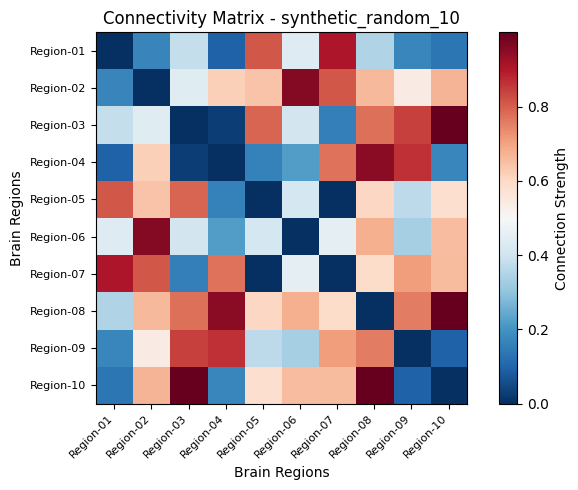

Displayed default connectivity matrix.

Test 2: Thresholded + log-scaled heatmap


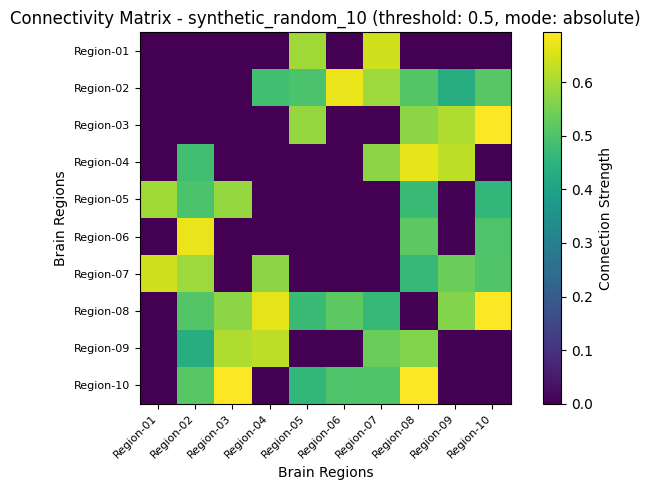

Displayed thresholded (>0.5), log-scaled matrix.



In [1]:
############################ Testing plot_matrix #############################
import clabtoolkit.connectivitytools as cltconn
import numpy as np

print('Testing plot_matrix visualization.')
print('---------------------------------------------------')

# Generate a random connectome with 10 regions and custom names 
region_names = [f'Region-{i+1:02d}' for i in range(10)]
conn = cltconn.Connectome.generate_connectome(10, region_names=region_names)

# Basic heatmap with region labels
print('Test 1: Default heatmap with labels')
conn.plot_matrix(figsize=(7, 5))
print('Displayed default connectivity matrix.')
print('')

# Thresholded heatmap, log scale, different colormap
print('Test 2: Thresholded + log-scaled heatmap')
conn.plot_matrix(
    figsize=(7, 5),
    cmap='viridis',
    threshold=0.5,
    threshold_mode='absolute',
    log_scale=True,
    show_labels=True,
)
print('Displayed thresholded (>0.5), log-scaled matrix.')
print('')

<a id="morphometry"></a>

## Morphometry

🔷 **2** · Parse FreeSurfer outputs and compute region-level morphometric values

---

<a id="parse-freesurfer-outputs"></a>

### Parse FreeSurfer Outputs

🔸 **2.1** · Utilities for reading FreeSurfer cortical statistics

---

<a id="parse_freesurfer_cortex_stats"></a>

#### `parse_freesurfer_cortex_stats`

🔹 **2.1.1** · Parse FreeSurfer cortical statistics files into a structured table

---


In [ ]:
################### Testing parse_freesurfer_cortex_stats ####################
import clabtoolkit.morphometrytools as cltmorpho
import os
import itables
import shutil

print('Testing parse_freesurfer_cortex_stats on aparc.stats files.')
print('---------------------------------------------------')

fs_dir = '/opt/freesurfer/subjects'
fs_id = 'bert'

# Parse a single hemisphere with default settings (metric format)
print('Test 1: Default parse, metric format')
stats_file = os.path.join(fs_dir, fs_id, 'stats', 'lh.aparc.stats')
df, _ = cltmorpho.parse_freesurfer_cortex_stats(stats_file)
print(f'Parsed {df["Region"].nunique()} regions, '
      f'metrics: {sorted(df["Metric"].unique())}')
itables.show(df)
print('')

# Parse selected metrics in region format and save the table and the BIDs entities to it
print('Test 2: Selected metrics, region format, saved to file')
stats_file = os.path.join(fs_dir, fs_id, 'stats', 'rh.aparc.stats')
bids_table = os.path.join('/tmp', f'sub-{fs_id}_ses-01_run-01_acq-mprage_hemi-L_desc-cortex_stats.txt')

shutil.copy(stats_file, bids_table)  # Copy the stats file to a new location with BIDs-like name for testing

output_table = os.path.join('/tmp', f'{fs_id}_rh_cortical-metrics.tsv')
df_region, saved_path = cltmorpho.parse_freesurfer_cortex_stats(
    bids_table,
    add_bids_entities=True,
    include_metrics=['area', 'volume', 'thickness'],
    output_table=output_table,
)
print(f'Saved table to: {saved_path}')
itables.show(df_region)
print('')


<a id="object-based-morphometry"></a>

### Object-Based Morphometry

🔸 **2.2** · Compute region-wise morphometric values from annotation files

---

<a id="compute_reg_val_fromannot"></a>

#### `compute_reg_val_fromannot`

🔹 **2.2.1** · Compute region-wise values (e.g. thickness, area) from an annotation file

---


In [ ]:
##################### Testing compute_reg_val_fromannot ######################
import os
import clabtoolkit.morphometrytools as morpho
import itables

print('Testing compute_reg_val_fromannot function with various parameters')
print('------------------------------------------------------------------')

# Setup common variables
hemi = 'lh'
metric_name = 'thickness'
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
metric_file = os.path.join(fs_dir, fs_id, 'surf', f'{hemi}.{metric_name}')
parc_file = os.path.join(fs_dir,  fs_id, 'label', f'{hemi}.aparc.annot')

# Test 1: Basic usage with metric format
print('\nTest 1: Basic usage with metric format')
print(f"Input: metric_file={metric_file}, parc_file={parc_file}, hemi={hemi}, metric={metric_name}, include_global=False")
df_region, metric_values, _ = morpho.compute_reg_val_fromannot(
    metric_file, 
    parc_file, 
    hemi, 
    metric=metric_name, 
    include_global=False,
    add_bids_entities=False, 
)
itables.show(df_region)

<a id="visualization"></a>

## Visualization

🔷 **3** · Plotting neuroimaging objects and composing 3-D scenes

---

<a id="plotting-objects"></a>

### Plotting Objects

🔸 **3.1** · Configure and render individual brain objects

---


In [ ]:
################################ Testing plot ################################
import clabtoolkit.visualizationtools as cltvis
import clabtoolkit.surfacetools as cltsurf
import os

# Load example surface data
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'fsaverage'
lh_pial = os.path.join(fs_dir, fs_id, 'surf', 'lh.pial')
lh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'lh.thickness')
lh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'lh.curv')
lh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'lh.sulc')
lh_annot = os.path.join(fs_dir, fs_id, 'label', 'lh.aparc.annot')


## Left Hemisphere
#  - Load surface
surf_lh = cltsurf.Surface(lh_pial)

#  - Load scalar maps
surf_lh.load_scalar_maps(lh_thickness, maps_names='thickness')
surf_lh.load_scalar_maps(lh_curvature, maps_names="curvature")
surf_lh.load_scalar_maps(lh_sulc, maps_names="sulc")
surf_lh.load_annotation(lh_annot, parc_name='aparc')

## Right Hemisphere
rh_pial = os.path.join(fs_dir, fs_id, 'surf', 'rh.pial')
rh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'rh.thickness')
rh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'rh.curv')
rh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'rh.sulc')
rh_annot = os.path.join(fs_dir, fs_id, 'label', 'rh.aparc.annot')

#  - Load surface
surf_rh = cltsurf.Surface(rh_pial)
#  - Load scalar maps
surf_rh.load_scalar_maps(rh_thickness, maps_names='thickness')
surf_rh.load_scalar_maps(rh_curvature, maps_names="curvature")
surf_rh.load_scalar_maps(rh_sulc, maps_names="sulc")
surf_rh.load_annotation(rh_annot, parc_name='aparc')

print("Test 1: Simple plot with single view...")
plotter = cltvis.BrainPlotter()
plotter.plot(
    objs2plot=surf_lh,
    views='lateral',
    map_names='thickness',
    colorbar=True,
    colorbar_position="bottom",
    colorbar_titles=["Cortical Thickness (mm)"],

)
print("Plot saved to /tmp/test_single_view.png")
print("-------------------------------")
print(" ")

print("Test 2: Plot with multiple views...")
plotter.plot(
    objs2plot=surf_lh,
    views=['lateral', 'medial', 'dorsal'],
    map_names='thickness',
    colormaps='jet',
    colorbar=True,
    save_path='/tmp/test_multi_view.png'
)
print("Plot saved to /tmp/test_multi_view.png")
print("-------------------------------")
print(" ")

print("Test 3: Plot with custom colormap limits...")
plotter.plot(
    objs2plot=surf_lh,
    views='lateral',
    map_names='thickness',
    v_limits=(1.5, 3.5),
    colormaps='coolwarm',
    colorbar=True,
    colorbar_position="bottom",
    colorbar_titles=["Cortical Thickness (mm)"],
    save_path='/tmp/test_custom_limits.png'
)
print("Plot saved to /tmp/test_custom_limits.png")
print("-------------------------------")
print(" ")

print("Test 4: Plot with value range (outlier coloring)...")
plotter.plot(
    objs2plot=surf_lh,
    views='lateral',
    map_names='thickness',
    v_range=(2.0, 3.0),  # Values outside this range will be gray
    range_color=(128, 128, 128, 255),
    colormaps='viridis',
    colorbar_position="bottom",
    colorbar_titles=["Cortical Thickness (mm)"],
    colorbar=True,
)
print("Plot saved with outlier coloring")
print("-------------------------------")
print(" ")

print("Test 5: Plot with list of objects same map...")
plotter.plot(
    objs2plot=[surf_lh, surf_rh],
    views='dorsal',
    map_names='thickness',
    colorbar_position="bottom",
    colorbar_titles=["Cortical Thickness (mm)"],
    colorbar_style="shared",
    colorbar=True,
)
print("Plot saved with multiple objects")
print("-------------------------------")
print(" ")

print("Test 6: Plot a single object with multiple maps...")
plotter.plot(
    objs2plot=[[surf_lh, surf_rh]],
    views='dorsal',
    map_names=['thickness', 'sulc'],
    colormaps=['viridis', 'coolwarm'],
    colorbar_position="bottom",
    colorbar_titles=["Cortical Thickness (mm)", "Sulc map (a.u)"],
    colorbar=True,
)
print("------------------------------")
print(" ")

print("Test 7: Plot with multiple surfaces and multiple views..." )
plotter.plot(   
        objs2plot = [[surf_lh, surf_rh], surf_lh, surf_rh],
        map_names = "thickness",
        hemi_id = ["lh", "rh"],
        views  = ["6_views"],
        views_orientation  = "horizontal",
        colormaps= ["jet"], 
        notebook = False,
        use_opacity=True,
        colorbar = True,
        colorbar_style="individual",
        colorbar_position = "bottom",
    )

print("------------------------------")
print(" ")

print("Test 8: Plot shared colorbar .." )
plotter.plot(   
        objs2plot = [[surf_lh, surf_rh], surf_lh, surf_rh],
        map_names = "thickness",
        hemi_id = ["lh", "rh"],
        views  = ["6_views"],
        views_orientation  = "horizontal",
        colormaps= ["jet"], 
        notebook = False,
        use_opacity=True,
        colorbar = True,
        colorbar_position="bottom",
        colorbar_titles=["Cortical Thickness (mm)"],
        colorbar_style="shared",
    )

Test 1: Simple plot with single view...
Number of views: 1, Number of maps: 1, Number of objects: 1
Plot saved to /tmp/test_single_view.png
-------------------------------
 
Test 2: Plot with multiple views...
Number of views: 3, Number of maps: 1, Number of objects: 1
Figure saved to: /tmp/test_multi_view.png
Plot saved to /tmp/test_multi_view.png
-------------------------------
 
Test 3: Plot with custom colormap limits...
Number of views: 1, Number of maps: 1, Number of objects: 1
Figure saved to: /tmp/test_custom_limits.png
Plot saved to /tmp/test_custom_limits.png
-------------------------------
 
Test 4: Plot with value range (outlier coloring)...
Number of views: 1, Number of maps: 1, Number of objects: 1
Plot saved with outlier coloring
-------------------------------
 
Test 5: Plot with list of objects same map...
Number of views: 1, Number of maps: 1, Number of objects: 2
Plot saved with multiple objects
-------------------------------
 
Test 6: Plot a single object with mult

<a id="plotting-scene"></a>

### Plotting Scene

🔸 **3.2** · Compose and export multi-object brain scenes

---


In [13]:
############################# Testing plot_scene #############################
import clabtoolkit.visualizationtools as cltvis
import clabtoolkit.tracttools as clttract
import clabtoolkit.surfacetools as cltsurf
import os

# Load example surface data
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'fsaverage'
lh_pial = os.path.join(fs_dir, fs_id, 'surf', 'lh.pial')
lh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'lh.thickness')
lh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'lh.curv')
lh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'lh.sulc')
lh_annot = os.path.join(fs_dir, fs_id, 'label', 'lh.aparc.annot')


## Left Hemisphere
#  - Load surface
surf_lh = cltsurf.Surface(lh_pial)

#  - Load scalar maps
surf_lh.load_scalar_maps(lh_thickness, maps_names='thickness')
surf_lh.load_scalar_maps(lh_curvature, maps_names="curvature")
surf_lh.load_scalar_maps(lh_sulc, maps_names="sulc")
surf_lh.load_annotation(lh_annot, parc_name='aparc')

## Right Hemisphere
rh_pial = os.path.join(fs_dir, fs_id, 'surf', 'rh.pial')
rh_thickness = os.path.join(fs_dir, fs_id, 'surf', 'rh.thickness')
rh_curvature = os.path.join(fs_dir, fs_id, 'surf', 'rh.curv')
rh_sulc = os.path.join(fs_dir, fs_id, 'surf', 'rh.sulc')
rh_annot = os.path.join(fs_dir, fs_id, 'label', 'rh.aparc.annot')

#  - Load surface
surf_rh = cltsurf.Surface(rh_pial)
#  - Load scalar maps
surf_rh.load_scalar_maps(rh_thickness, maps_names='thickness')
surf_rh.load_scalar_maps(rh_curvature, maps_names="curvature")
surf_rh.load_scalar_maps(rh_sulc, maps_names="sulc")
surf_rh.load_annotation(rh_annot, parc_name='aparc')

# Loading some tracts
in_trk1 = os.path.join(fs_home, "trctrain","hcp","mni","cc.bodyc.display.trk")
in_trk2 = os.path.join(fs_home, "trctrain","hcp","mni","cc.bodypf.display.trk")

# Loading 2 tract objects with colors
tract_obj1 = clttract.Tractogram(in_trk1, color="#FF0000FF")
tract_obj2 = clttract.Tractogram(in_trk2, color="#0000FFFF")

## Initialize BrainPlotter
plotter = cltvis.BrainPlotter()

print("Test 1: Plot scene with custom configuration...")
scene_objects = [surf_lh, tract_obj1, tract_obj2]

scene_config = {
    0: {  # Configuration for first object
        'map_name': 'default',
        'colormap': 'gray',
        'v_limits': (None, None),
        'v_range': (None, None),
        'opacity': 0.8
    },
    1: {  # Configuration for second object
        'map_name': 'default',
        'colormap': 'gray',
        'v_limits': (None, None),
        'v_range': (None, None),
        'opacity': 0.8
    }
}
plotter.plot_scene(
    scene_objects=scene_objects,
    scene_config=scene_config,
    views='dorsal',
)
print("-------------------------------")
print(" ")

print("Test 3: Plot scene with multiple views...")
plotter.plot_scene(
    scene_objects=scene_objects,
    views=['dorsal', 'ventral', 'lateral'],
)
print("-------------------------------")
print(" ")


Test 1: Plot scene with custom configuration...
-------------------------------
 
Test 3: Plot scene with multiple views...
-------------------------------
 


<a id="other-examples"></a>

## Other examples

🔷 **4** · Other examples of the usage of CLABTOOLKIT features

---


In [ ]:
######################## Testing invert_colors ###################################
import clabtoolkit.colorstools as cltcol
import numpy as np

print('Testing invert_colors function with various RGB values.')
print('---------------------------------------------------')

# Test with a list of RGB values
print('Test 1: List of RGB values') 
rgb_values = [[255, 0, 0], [0, 255, 0], [0, 0, 255]]

inverted_colors = cltcol.invert_colors(rgb_values)
print(f'The colors {np.array(rgb_values)} inverted are: {inverted_colors}')
print('')

# Test with a numpy array of RGB values
print('Test 2: Numpy array of RGB values')
rgb_values = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255]])
inverted_colors = cltcol.invert_colors(rgb_values)
print(f'The colors {np.array(rgb_values)} inverted are: {inverted_colors}')

# Test with a list of hex colors and float colors
print('Test 3: List of hex colors and float colors')
rgb_values = ['#ff0000', '#00ff00', [0.0, 0.0, 1.0], [0, 255, 243], np.array([0.0, 0.0, 1.0]), np.array([0, 255, 243])]
inverted_colors = cltcol.invert_colors(rgb_values)
print('The colors: ')
for val in rgb_values:
    print(val)
print('inverted are:')
print(inverted_colors)
print('')

In [ ]:
######################## Testing harmonize_colors ###################################

import clabtoolkit.colorstools as cltcol
import numpy as np

print('Test 1: Harmonize colors with hex output format')
rgb_values = [[255, 0, 0], '#00ff00', [0, 0, 255], np.array([0.0, 0.0, 1.0])]   
hex_colors = cltcol.harmonize_colors(rgb_values, output_format='hex')
print(hex_colors)

print('Test 2: Harmonize colors with RGB output format')
rgb_values = [[255, 0, 0], '#00ff00', [0, 0, 255], np.array([0.0, 0.0, 1.0])]
rgb_colors = cltcol.harmonize_colors(rgb_values, output_format='RGB')
print(rgb_colors)


In [ ]:
######################## Testing readjust_colors ###################################
import clabtoolkit.colorstools as cltcol
import numpy as np

print('Test 1: Readjust colors with multiple formats to normalized RGB format')
rgb_values = [[1, 0, 0], '#00ff00', [0, 0, 255], np.array([0.0, 0.0, 1.0])]
adj_colors = cltcol.readjust_colors(rgb_values, output_format='rgbnorm')
print(adj_colors)
print('')

print('Test 2: Readjust colors with multiple formats to hex format')
rgb_values = [[1, 0, 0], '#00ff00', [0, 0, 255], np.array([0.0, 0.0, 1.0])]
adj_colors = cltcol.readjust_colors(rgb_values, output_format='hex')
print(adj_colors)
print('')

print('Test 3: Readjust colors with multiple formats to RGB format')
rgb_values = [[0.89, 0.0, 0.0], '#00ff00', [0, 0, 255], np.array([0.0, 0.0, 1.0])]
adj_colors = cltcol.readjust_colors(rgb_values, output_format='RGB')
print(adj_colors)
print('')

In [ ]:
######################## Testing replace_entity_value ###################################

import clabtoolkit.bidstools as cltbids

filename = 'sub-01_ses-M00_acq-3T_dir-AP_run-01_T1w.nii.gz'

print('Test 1: Replace the acq value from 3T to 7T in a string:')
result = cltbids.replace_entity_value(filename, {'acq': '7T'})
print(result)
print('')

print('Test 2: Replace multiple entity values at once:')
result = cltbids.replace_entity_value(filename, {'acq': '7T', 'dir': 'PA', 'run': '02'})
print(result)
print('')

print('Test 3: Replace value using a BIDS string as the replacement dictionary:')
result = cltbids.replace_entity_value(filename, 'acq-7T_dir-PA')
print(result)
print('')

print('Test 4: Attempt to replace a non-existent key with verbose=True:')
result = cltbids.replace_entity_value(filename, {'task': 'rest'}, verbose=True)
print(result)
print('')

print('Test 5: Replace entity value in a dictionary (dict input/output):')
entity = cltbids.str2entity(filename)
result = cltbids.replace_entity_value(entity, {'ses': 'M24'})
print(result)
print('')

In [ ]:
######################## Testing insert_entity ###################################

import clabtoolkit.bidstools as cltbids

filename = 'sub-01_ses-M00_acq-3T_dir-AP_run-01_T1w.nii.gz'

print('Test 1: Append a new entity (task) at the end of the name (before suffix):')
result = cltbids.insert_entity(filename, {'task': 'rest'})
print(result)
print('')

print('Test 2: Insert entity immediately after the ses key:')
result = cltbids.insert_entity(filename, {'task': 'rest'}, prev_entity='ses')
print(result)
print('')

print('Test 3: Insert multiple entities at once after the ses key:')
result = cltbids.insert_entity(filename, {'task': 'rest', 'echo': '1'}, prev_entity='ses')
print(result)
print('')

print('Test 4: Try to insert an entity that already exists (should be skipped):')
result = cltbids.insert_entity(filename, {'acq': '7T'})
print(result)
print('')

print('Test 5: Insert entity into a dictionary (dict input/output):')
entity = cltbids.str2entity(filename)
result = cltbids.insert_entity(entity, {'part': 'mag'}, prev_entity='run')
print(result)
print('')

In [ ]:
########################### Testing surface_extraction ###########################
import clabtoolkit.parcellationtools as cltparc
import os
fs_home = os.environ.get('FREESURFER_HOME')
fs_dir = os.path.join(fs_home, 'subjects')
fs_id = 'bert'
parc_id = 'aparc+aseg.mgz'
parc_file = os.path.join(fs_dir, fs_id, 'mri', f'{parc_id}')
lut_file = os.path.join(fs_home, 'FreeSurferColorLUT.txt')

############## Loading from a file ###################################
parc = cltparc.Parcellation(parc_file, color_table=lut_file)

# Example 1: Extract a surface mesh for specific codes
print('Test 1: Extracting surface mesh for specific codes and returning a list of the extracted meshes...')
codes_to_extract = [10, 49, 8, 47]  # Example codes (Thalamus and Cerebellum Cortex)
surf_list = parc.surface_extraction(roi_codes=codes_to_extract, merge_surfaces=False)
print("Number of surfaces extracted:", len(surf_list))
# surf_list[0].plot() # Uncomment to plot the first surface
print("-------------------------------")
print(" ")

# Example 2: Extract a surface mesh for all regions and save the annotation to a file
print('Test 2: Extracting surface mesh for specific names and saving to a file with annotation...')
names_to_extract = ['Thalamus', 'Caudate', 'Pallidum']  # Example names
merged_surf = parc.surface_extraction(roi_names= names_to_extract,
                                    out_filename="/tmp/merged_surf.freesurfer",
                                    overwrite=True,
                                    save_annotation=True)
print(f"Surface mesh and annotation saved to /tmp/merged_surf.freesurfer and /tmp/merged_surf.annot")
print(f"Open the surface mesh in Freeview with the command: freeview -f /tmp/merged_surf.freesurfer:annotation=/tmp/merged_surf.annot",)
os.system(f"freeview -f /tmp/merged_surf.freesurfer:annotation=/tmp/merged_surf.annot")
print("-------------------------------")
print(" ")

# Example 3: Extract a surface mesh for all regions, merging them into a single mesh with names
print('Test 3: Extracting surface mesh for specific names and merging into a single mesh...')
names_to_extract = ['Thalamus', 'Caudate', 'Pallidum']  # Example names
merged_surf = parc.surface_extraction(roi_names= names_to_extract, merge_surfaces=True)
print("Merged surface mesh:")
print(merged_surf)
merged_surf.plot()
print("-------------------------------")
print(" ")





In [ ]:
######################## Testing visualize_colors ###################################

import clabtoolkit.misctools as cltmisc

dates_list = ["20230101", "20230201", "20230301"]
target_date = "20230215"
closest_date, closest_index, time_diff = cltmisc.find_closest_date(dates_list, target_date)

print(f"Closest date to {target_date} is {closest_date} at index {closest_index} with a time difference of {time_diff} days.")

In [ ]:
######################## Testing get_indices_by_condition ###################################
import clabtoolkit.misctools as cltmisc
import numpy as np
# Test with a list of indices including integers, tuples, lists, and strings
print('Test 1: List of indices including integers, tuples, lists, and strings')
range_vector = [1, (2, 5), [6, 7], np.array([0, 0, 0]),  "8-10", "11:13", "14:2:22"]
indexes = cltmisc.build_indices(range_vector)
print(f'Indexes: {indexes}')
print('')

In [ ]:
######################## Testing get_indices_by_condition ###################################
import clabtoolkit.misctools as cltmisc
import numpy as np

print('Testing get_indices_by_condition function with various conditions.')
print('---------------------------------------------------')

bvals = np.array([0, 500, 1000, 1000, 2000, 3000, 0, 0, 0, 40000, 2500])

# Test 1: Simple condition. Find indices in b that ar different from tmp_max_bval
print('Test 1: Simple condition. Find indices in b that are different from tmp_max_bval')
print(cltmisc.get_indices_by_condition("b != tmp_max_bval", b=bvals, tmp_max_bval=2500))
print( " ")

# Test 2: Simple condition. Find indices in bvals that are higher or equal to bmin and lower or equal than bmax
print('Test 2: Simple condition. Find indices in bvals that are higher or equal to bmin and lower or equal than bmax')
print(cltmisc.get_indices_by_condition("bmin <= bvals <= bmax", bvals=bvals, bmin=800, bmax=2500))
print( " ")

# Test 3: Simple condition. Find indices in bvals that are higher or equal to 1000 and lower or equal than bmax
print('Test 3: Simple condition. Find indices in bvals that are higher or equal to 1000 and lower or equal than bmax. Embedding the 1000 in the condition')
print(cltmisc.get_indices_by_condition("1000 <= bvals <= bmax", bvals=bvals, bmin=800, bmax=2500))
print( " ")

# Test 4: Simple condition. Find indices in bvals that are higher or equal to 1000 and lower or equal than 2000
print('Test 4: Simple condition. Find indices in bvals that are higher or equal to 1000 and lower or equal than bmax. Embedding the both values in the condition')
print(cltmisc.get_indices_by_condition("1000 <= bvals <= 2000", bvals=bvals, bmin=800, bmax=2500))
print( " ")

# Test 5: Simple condition. Find indices in bvals that are higher than bmin
print('Test 5: Simple condition. Find indices in bvals that are higher than bmin')
print(cltmisc.get_indices_by_condition("bvals > bmin", bvals=bvals, bmin=1000))
print( " ")

# Test 6: Simple condition. Find indices in bvals that are lower than bmax
print('Test 6: Simple condition. Find indices in bvals that are lower than bmax')
print(cltmisc.get_indices_by_condition("bvals < bmax", bvals=bvals, bmax=1000))
print( " ")

# Test 7: Simple condition. Find indices in bvals that are equal to bval
print('Test 7: Simple condition. Find indices in bvals that are equal to bval')
print(cltmisc.get_indices_by_condition("bvals == bval", bvals=bvals, bval=1000))
print( " ")